In [1]:
import numpy as np
import pyvisa as visa
from instrumentlib import KeysightXSeries, RhodeandSchwarz_SGS100A
import time
import matplotlib.pyplot as plt
from qm.qua import *
from qm import QuantumMachinesManager
from configuration_4qubitsv1 import *
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
qmm = QuantumMachinesManager()
qm = qmm.open_qm(config)
address = "TCPIP0::192.168.0.117::inst0::INSTR"
calib = KeysightXSeries(address)

2023-04-06 14:14:00,767 - qm - INFO - Performing health check
2023-04-06 14:14:00,774 - qm - INFO - Health check passed


In [4]:
qe_freq = {}
for i in range(1,3):
    qe_freq[f"q{i}"] = [q_LO[f"{i}"], q_IF[f"{i}"], f"mixer_q{i}"]
    qe_freq[f"rr{i}"] = [rr_LO[f"{i}"], rr_IF[f"{i}"], f"mixer_rr{i}"]

In [5]:
qe = "q1"
qe_LO, qe_IF, mixer = qe_freq[qe]
center_freq = qe_LO + qe_IF  #rr_LO
span = 50
calib.set_bandwidth(3)
calib.set_sweep_points(501)

calib.set_center_freq(center_freq)
calib.set_span(span)
calib.active_marker(1)
calib.set_marker_freq(1, center_freq)

In [20]:
with program() as mixtest:

    n = declare(int)
#     frame_rotation(0.25, qe)
    with infinite_loop_():
        
       play("const", qe)

job = qm.execute(mixtest)

2023-04-06 15:04:54,189 - qm - INFO - Flags: 
2023-04-06 15:04:54,190 - qm - INFO - Sending program to QOP
2023-04-06 15:04:54,221 - qm - INFO - Executing program


In [15]:
address_rf = "TCPIP0::192.168.0.200::inst0::INSTR"
rf_input = RhodeandSchwarz_SGS100A(address_rf)

In [16]:
freq = 6 # GHz
power = 8 #dBm
rf_input.set_freq_GHz(freq)
rf_input.set_power_dB(power)

In [17]:
rf_input.output_toggle()

In [23]:
pmin, pmax, dp = 8, 16, 0.5
power_list_mxp = np.arange(pmin, pmax, dp)

output_list = []
for power in power_list_mxp:
    
    rf_input.set_power_dB(power)
    time.sleep(2)
    p = calib.query_marker(1)
    output_list.append(p)

In [24]:
output_list_MXP = output_list

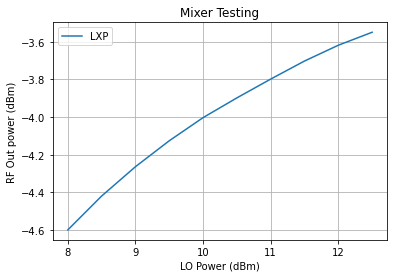

In [13]:
plt.plot(power_list, output_list_LXP, label = "LXP")
plt.xlabel("LO Power (dBm)")
plt.ylabel("RF Out power (dBm)")
plt.title("Mixer Testing")
plt.legend()
plt.grid()
plt.show()

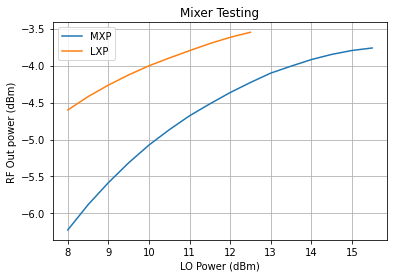

In [26]:
plt.plot(power_list_mxp, output_list_MXP, label = "MXP")
plt.plot(power_list, output_list_LXP, label = "LXP")
plt.xlabel("LO Power (dBm)")
plt.ylabel("RF Out power (dBm)")
plt.title("Mixer Testing")
plt.legend()
plt.grid()
plt.show()